## 1.5 양자 순간이동 — 정보의 즉각 전송 (Quantum Teleportation)

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 큐비트 3개 + 고전 비트 3개로 양자 회로 생성
qc = QuantumCircuit(3, 3)

In [3]:
# 1단계: 큐비트 1과 큐비트 2를 얽어 얽힘쌍 생성
qc.h(1)
qc.cx(1, 2)

In [4]:
# 2단계: 순간이동시킬 상태를 큐비트 0에 준비
qc.x(0)

In [5]:
# 3단계: 큐비트 0과 큐비트 1에 벨 측정 수행
qc.cx(0, 1)
qc.h(0)
qc.measure([0, 1], [0, 1])

In [6]:
# 4단계: 측정 결과에 따른 조건부 연산 적용
qc.cx(1, 2)
qc.cz(0, 2)

In [7]:
# 순간이동된 큐비트 측정
qc.measure(2, 2)

In [8]:
# Qiskit Aer 시뮬레이터로 회로 실행
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
result = simulator.run(compiled_circuit).result()

In [9]:
# 측정 결과 집계
counts = result.get_counts()
print("Counts:", counts)

Counts: {'110': 245, '111': 219, '100': 269, '101': 291}


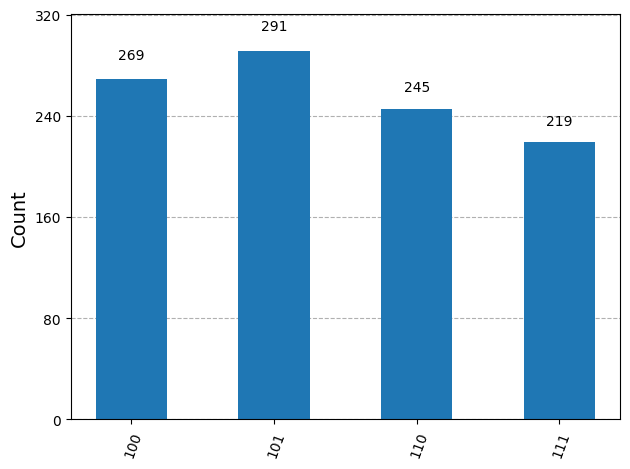

In [10]:
# 측정 결과 시각화
plot_histogram(counts)
plt.show()

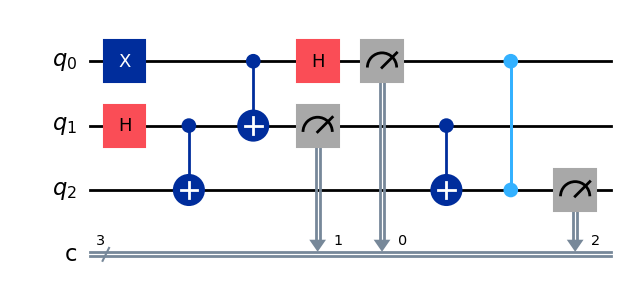

In [11]:
# 회로 그리기
qc.draw('mpl')
plt.show()